In [1]:
import math
import random
import sklearn.datasets
import matplotlib.pyplot as plt

from micrograd.engine import Value
from micrograd.nn import MLP

In [2]:
def value_exp(value: Value) -> Value:
    """Calculate exp function for Value."""
    x = value.data
    out = Value(math.exp(x), (value,), "exp")

    def _backward():
        value.grad += out.data * out.grad
    out._backward = _backward
    
    return out

def value_log(value: Value) -> Value:
    """Calculate log function for Value."""
    # Add very small value to avoid log(0.0) problem
    x = value.data + 1e-15
    out = Value(math.log(x), (value,), "ln")

    def _backward():
        value.grad += (1 / x) * out.grad
    out._backward = _backward

    return out

def max_value(values_list: list[Value]) -> Value:
    """Find max Value from list."""
    values_data = [value.data for value in values_list]
    max_value_data = max(values_data)
    max_index = values_data.index(max_value_data)
    return values_list[max_index]

In [3]:
def safe_softmax(values: list[Value]) -> list[Value]:
    """Safe softmax function.
    
    https://en.wikipedia.org/wiki/Softmax_function 

    """
    result_values: list[Value] = []
    beta = Value(1.0)
    largest_factor = max_value(values)
    denominator = sum(
        value_exp(beta * (number - largest_factor))
        for number in values
    )
    for value in values:
        numerator = value_exp(beta * (value - largest_factor)) 
        result_values.append(numerator / denominator)
    return result_values

In [4]:
iris_dataset = sklearn.datasets.load_iris()
iris_dataset

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [5]:
print(f"Length of input values: {len(iris_dataset["data"][0])}")
print(f"Number of input values: {len(iris_dataset["data"])}")
targets_number = len(iris_dataset["target_names"])
print(f"Number of targets: {targets_number}")
print(f"Target names: {iris_dataset["target_names"]}")

Length of input values: 4
Number of input values: 150
Number of targets: 3
Target names: ['setosa' 'versicolor' 'virginica']


In [6]:
# Shuffle data before split
indexes = list(range(len(iris_dataset["data"])))
random.seed(42)
random.shuffle(indexes)
X_all = iris_dataset["data"][indexes]
y_all = iris_dataset["target"][indexes]

In [7]:
# 70% of original dataset
train_dataset_size = int(len(iris_dataset["data"]) * 0.7)

X_train = X_all[:train_dataset_size]
y_train = y_all[:train_dataset_size]

X_test = X_all[train_dataset_size:]
y_test = y_all[train_dataset_size:]
print(f"Length of train dataset: {len(X_train)}")
print(f"Length of test dataset: {len(X_test)}")

Length of train dataset: 105
Length of test dataset: 45


In [8]:
mlp = MLP(4, [16, 16, 3])

In [9]:
mlp.layers

[Layer of [ReLUNeuron(4), ReLUNeuron(4), ReLUNeuron(4), ReLUNeuron(4), ReLUNeuron(4), ReLUNeuron(4), ReLUNeuron(4), ReLUNeuron(4), ReLUNeuron(4), ReLUNeuron(4), ReLUNeuron(4), ReLUNeuron(4), ReLUNeuron(4), ReLUNeuron(4), ReLUNeuron(4), ReLUNeuron(4)],
 Layer of [ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16)],
 Layer of [LinearNeuron(16), LinearNeuron(16), LinearNeuron(16)]]

In [10]:
print("number of parameters", len(mlp.parameters()))

number of parameters 403


In [11]:
type VectorsList = list[list[int]]

def get_targets_list(
    targets_number: int,
    targets: list[int],
    targets_indexes: list[int] | None = None,
) -> VectorsList:
    """Transform each index of the target to the list of zeroes and one."""
    targets_list: VectorsList = []
    if targets_indexes:
        for index in targets_indexes:
            target = targets[index]
            zeroes_list = [0] * targets_number
            zeroes_list[target] = 1
            targets_list.append(zeroes_list)
    else:
        for target in targets:
            zeroes_list = [0] * targets_number
            zeroes_list[target] = 1
            targets_list.append(zeroes_list)
    return targets_list

In [ ]:
type ValuesVectorsList = list[list[Value]] 

def loss(
    dataset: list[list[float]],
    targets: list[int],
    targets_number: int,
    batch_size: int | None = None,
) -> tuple[Value, float]:
    """CrossEntropyLoss function.

    https://en.wikipedia.org/wiki/Cross-entropy

    """
    if not batch_size:
        dataset_targets = get_targets_list(
            targets_number=targets_number,
            targets=targets,
        ) 
    else:
        random_permutation_indexes = random.sample(
            range(len(dataset)),
            batch_size,
        )
        dataset = [
            dataset[index]
            for index in random_permutation_indexes
        ]
        dataset_targets: VectorsList = get_targets_list(
            targets_number=targets_number,
            targets=targets,
            targets_indexes=random_permutation_indexes,
        )

    inputs = [list(map(Value, xrow)) for xrow in dataset]
    scores: ValuesVectorsList = [mlp(input_values) for input_values in inputs]

    right_answers_number = 0 
    for index, score in enumerate(scores):
        score_list = [value.data for value in score]
        argmax = max(score_list) 
        argmax_index = score_list.index(argmax)
        target_index = dataset_targets[index].index(1)
        if argmax_index == target_index:
            right_answers_number += 1

    losses: list[Value] = []
    for index, score in enumerate(scores):
        probs = safe_softmax(score)
        sample_loss = -sum(
            dataset_targets[index][target] * value_log(probs[target])
            for target in range(targets_number)
        )
        losses.append(sample_loss)

    mean_loss = sum(losses) / len(scores) 
    accuracy = right_answers_number / len(scores)

    return mean_loss, accuracy

In [13]:
train_accuracy = 0
for step in range(100):
    # forward pass
    mean_loss, accuracy = loss(
        dataset=X_train,
        targets=y_train,
        targets_number=targets_number,
    )
    train_accuracy = accuracy
    
    # backward
    mlp.zero_grad()
    mean_loss.backward()

    learning_rate = 0.01
    for parameter in mlp.parameters():
        parameter.data -= learning_rate * parameter.grad
    
    if step % 1 == 0:
        print(f"step {step} loss {mean_loss.data}, accuracy {accuracy*100}%")

step 0 loss 11.346019688585, accuracy 27.61904761904762%
step 1 loss 4.062954902889469, accuracy 0.9523809523809524%
step 2 loss 1.8665023179643927, accuracy 2.857142857142857%
step 3 loss 1.4162207838948895, accuracy 2.857142857142857%
step 4 loss 1.1142493221421865, accuracy 25.71428571428571%
step 5 loss 0.9724642786248335, accuracy 32.38095238095238%
step 6 loss 0.8718561122181331, accuracy 33.33333333333333%
step 7 loss 0.7869528010334377, accuracy 42.857142857142854%
step 8 loss 0.7021206156768766, accuracy 63.8095238095238%
step 9 loss 0.6311957820394059, accuracy 68.57142857142857%
step 10 loss 0.568116014772388, accuracy 85.71428571428571%
step 11 loss 0.5159503467677543, accuracy 91.42857142857143%
step 12 loss 0.4835395611844681, accuracy 93.33333333333333%
step 13 loss 0.46768263985134423, accuracy 94.28571428571428%
step 14 loss 0.4563311514632131, accuracy 94.28571428571428%
step 15 loss 0.44618921026011665, accuracy 95.23809523809523%
step 16 loss 0.43677387375840715, ac

In [14]:
def inference(input_data: list[float]) -> int:
    """Predict target class from input data."""
    scores = mlp(list(map(Value, input_data)))
    score_list = [value.data for value in scores]
    argmax = max(score_list) 
    argmax_index = score_list.index(argmax)
    return argmax_index

In [15]:
right_answers = 0
for X, y in zip(X_test, y_test):
    predict_label = inference(X)
    if predict_label == y:
        right_answers += 1
test_accuracy = right_answers / len(y_test)
print(f"Total accuracy on test dataset: {test_accuracy * 100}%")

Total accuracy on test dataset: 100.0%


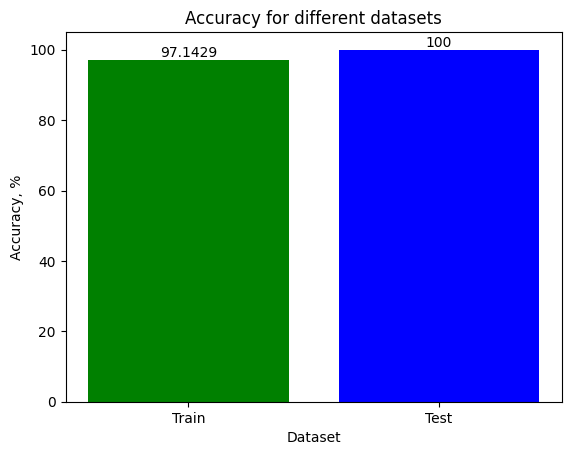

In [16]:
labels = ["Train", "Test"]
values = [train_accuracy * 100, test_accuracy * 100]
colors = ["green", "blue"]
bars = plt.bar(
    labels,
    values, 
    color=colors,
)
plt.bar_label(bars)
plt.xlabel("Dataset")
plt.ylabel("Accuracy, %")
plt.title("Accuracy for different datasets")
plt.show()